# Audit EVE V0.1 — Decision points & épisodes — site_004

Objectif : vérifier que les points de décision et les épisodes générés par EVE V0.1 sont cohérents, traçables et scientifiquement défendables.

Ce notebook ne recalcule pas les règles métier. Il lit les fichiers produits par la mission épisodes et sert uniquement à l’audit visuel et statistique.

In [2]:
from pathlib import Path
import json
import yaml

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
PROJECT_ROOT = Path("..").resolve()

DATA_DIR = PROJECT_ROOT / "data" / "processed"
CONFIG_DIR = PROJECT_ROOT / "config"

DECISION_POINTS_PATH = DATA_DIR / "eve_decision_points_site_004.csv"
EPISODES_PATH = DATA_DIR / "eve_episodes_site_004.csv"
BASELINE_PATH = DATA_DIR / "eve_baseline_site_004.json"

RULES_PATH = CONFIG_DIR / "episode_rules_v0_1.yaml"
COSTS_PATH = CONFIG_DIR / "verification_costs_v0_1.yaml"

for path in [
    DECISION_POINTS_PATH,
    EPISODES_PATH,
    BASELINE_PATH,
    RULES_PATH,
    COSTS_PATH,
]:
    print(path, "OK" if path.exists() else "MISSING")

D:\Compte ASUS\Desktop\Eve\data\processed\eve_decision_points_site_004.csv OK
D:\Compte ASUS\Desktop\Eve\data\processed\eve_episodes_site_004.csv OK
D:\Compte ASUS\Desktop\Eve\data\processed\eve_baseline_site_004.json OK
D:\Compte ASUS\Desktop\Eve\config\episode_rules_v0_1.yaml OK
D:\Compte ASUS\Desktop\Eve\config\verification_costs_v0_1.yaml OK


In [4]:
decision_points = pd.read_csv(DECISION_POINTS_PATH)
episodes = pd.read_csv(EPISODES_PATH)

with open(BASELINE_PATH, "r", encoding="utf-8") as f:
    baseline = json.load(f)

with open(RULES_PATH, "r", encoding="utf-8") as f:
    rules = yaml.safe_load(f)

with open(COSTS_PATH, "r", encoding="utf-8") as f:
    costs = yaml.safe_load(f)

# Conversion dates
for col in ["acquisition_date", "date"]:
    if col in decision_points.columns:
        decision_points[col] = pd.to_datetime(decision_points[col], errors="coerce")

for col in ["episode_start_date", "episode_end_date", "peak_date"]:
    if col in episodes.columns:
        episodes[col] = pd.to_datetime(episodes[col], errors="coerce")

print("Decision points:", decision_points.shape)
print("Episodes:", episodes.shape)

Decision points: (1479, 72)
Episodes: (32, 34)


In [5]:
print("=== Baseline ===")
for key in ["baseline_version", "evaluation_mode", "site_id", "generated_at"]:
    if key in baseline:
        print(f"{key}: {baseline[key]}")

print("\n=== Rules ===")
for key in ["rules_version", "decision_rules_version", "season_months"]:
    if key in rules:
        print(f"{key}: {rules[key]}")

print("\n=== Colonnes decision_points ===")
print(decision_points.columns.tolist())

print("\n=== Colonnes episodes ===")
print(episodes.columns.tolist())

=== Baseline ===
baseline_version: monthly_reference_2016_2025_v0.1_site_004_retrospective_loyo
evaluation_mode: retrospective_loyo
site_id: site_004
generated_at: 2026-06-22T16:54:47+00:00

=== Rules ===
rules_version: v0.1
season_months: [4, 5, 6, 7, 8, 9, 10]

=== Colonnes decision_points ===
['decision_point_id', 'parcel_id', 'acquisition_date', 'evaluation_mode', 'rules_version', 'baseline_version', 'baseline_reference_years', 'baseline_start_date', 'baseline_end_date', 'generated_at', 'in_scope_season', 'eligible_for_analysis', 'eligibility_reason', 'ndmi_value', 'ndmi_monthly_median', 'ndmi_anomaly_value', 'ndmi_percentile', 'ndmi_reference_count', 'ndmi_state', 'valid_pixel_ratio', 'satellite_quality', 'water_balance_30d_value', 'water_balance_30d_monthly_median', 'water_balance_30d_anomaly_value', 'water_balance_30d_percentile', 'water_balance_reference_count', 'water_balance_state', 'soil_moisture_30d_value', 'soil_moisture_30d_monthly_median', 'soil_moisture_30d_anomaly_valu

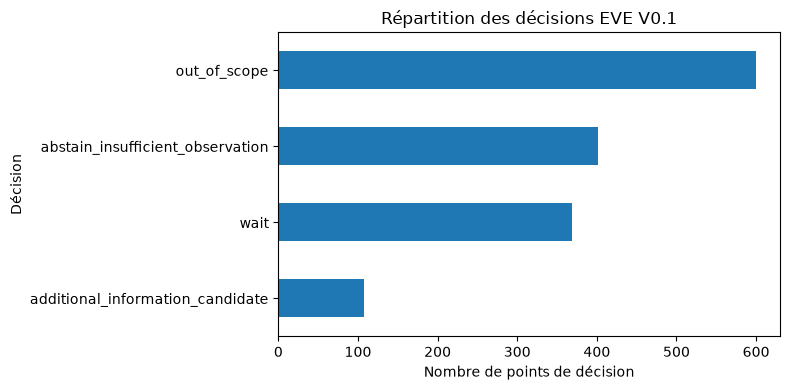

In [6]:
summary = {
    "total_acquisitions": len(decision_points),
    "out_of_scope": (decision_points["eve_decision"] == "out_of_scope").sum(),
    "insufficient_observation": (decision_points["eve_decision"] == "abstain_insufficient_observation").sum(),
    "wait": (decision_points["eve_decision"] == "wait").sum(),
    "candidates": decision_points["is_candidate"].sum(),
    "episodes": len(episodes),
}

summary_df = pd.DataFrame(summary.items(), columns=["metric", "value"])
summary_df

fig, ax = plt.subplots(figsize=(8, 4))

decision_counts = decision_points["eve_decision"].value_counts().sort_values()
decision_counts.plot(kind="barh", ax=ax)

ax.set_title("Répartition des décisions EVE V0.1")
ax.set_xlabel("Nombre de points de décision")
ax.set_ylabel("Décision")

plt.tight_layout()
plt.show()

,count
recommended_information_action,
none,969
wait_next_sentinel,402
review_raster,57
priority_field_check,42
field_check,9


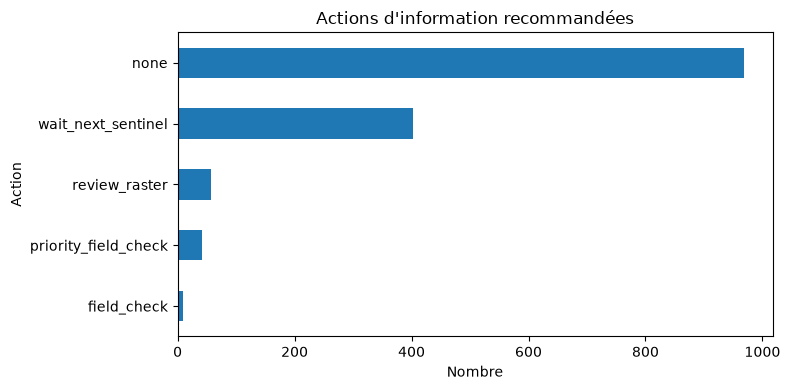

In [7]:
if "recommended_information_action" in decision_points.columns:
    action_counts = decision_points["recommended_information_action"].value_counts(dropna=False)

    display(action_counts.to_frame("count"))

    fig, ax = plt.subplots(figsize=(8, 4))
    action_counts.sort_values().plot(kind="barh", ax=ax)

    ax.set_title("Actions d'information recommandées")
    ax.set_xlabel("Nombre")
    ax.set_ylabel("Action")

    plt.tight_layout()
    plt.show()

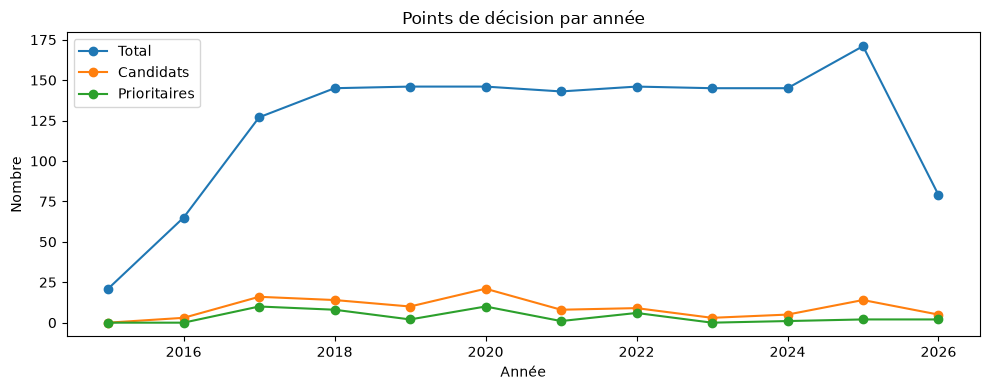

In [8]:
date_col = "acquisition_date" if "acquisition_date" in decision_points.columns else "date"

decision_points["year"] = decision_points[date_col].dt.year
decision_points["month"] = decision_points[date_col].dt.month

annual = (
    decision_points
    .groupby("year")
    .agg(
        total=("decision_point_id", "count"),
        candidates=("is_candidate", "sum"),
        priority=(
            "recommended_information_action",
            lambda s: (s == "priority_field_check").sum()
        ),
    )
    .reset_index()
)

annual["candidate_rate"] = annual["candidates"] / annual["total"]

annual

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(annual["year"], annual["total"], marker="o", label="Total")
ax.plot(annual["year"], annual["candidates"], marker="o", label="Candidats")
ax.plot(annual["year"], annual["priority"], marker="o", label="Prioritaires")

ax.set_title("Points de décision par année")
ax.set_xlabel("Année")
ax.set_ylabel("Nombre")
ax.legend()

plt.tight_layout()
plt.show()

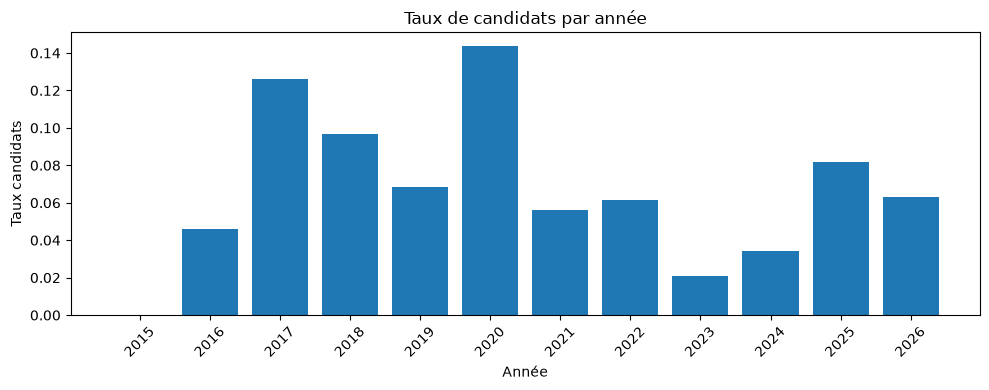

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(annual["year"].astype(str), annual["candidate_rate"])

ax.set_title("Taux de candidats par année")
ax.set_xlabel("Année")
ax.set_ylabel("Taux candidats")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

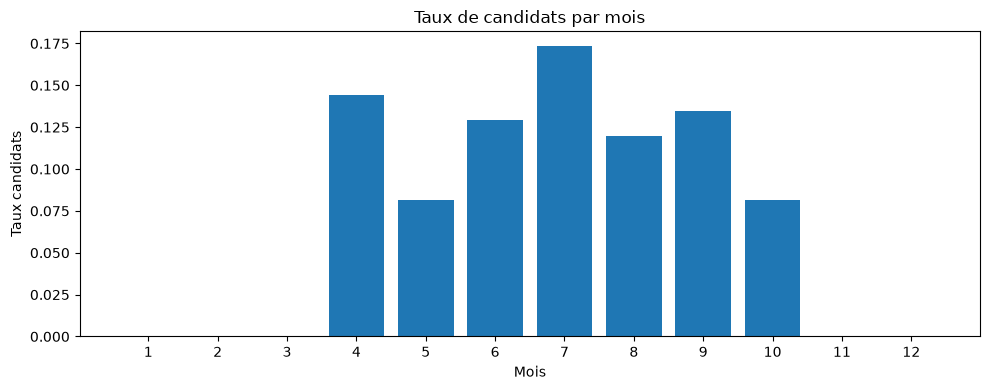

In [10]:
monthly = (
    decision_points
    .groupby("month")
    .agg(
        total=("decision_point_id", "count"),
        candidates=("is_candidate", "sum"),
        priority=(
            "recommended_information_action",
            lambda s: (s == "priority_field_check").sum()
        ),
    )
    .reset_index()
)

monthly["candidate_rate"] = monthly["candidates"] / monthly["total"]
monthly

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(monthly["month"].astype(str), monthly["candidate_rate"])

ax.set_title("Taux de candidats par mois")
ax.set_xlabel("Mois")
ax.set_ylabel("Taux candidats")

plt.tight_layout()
plt.show()

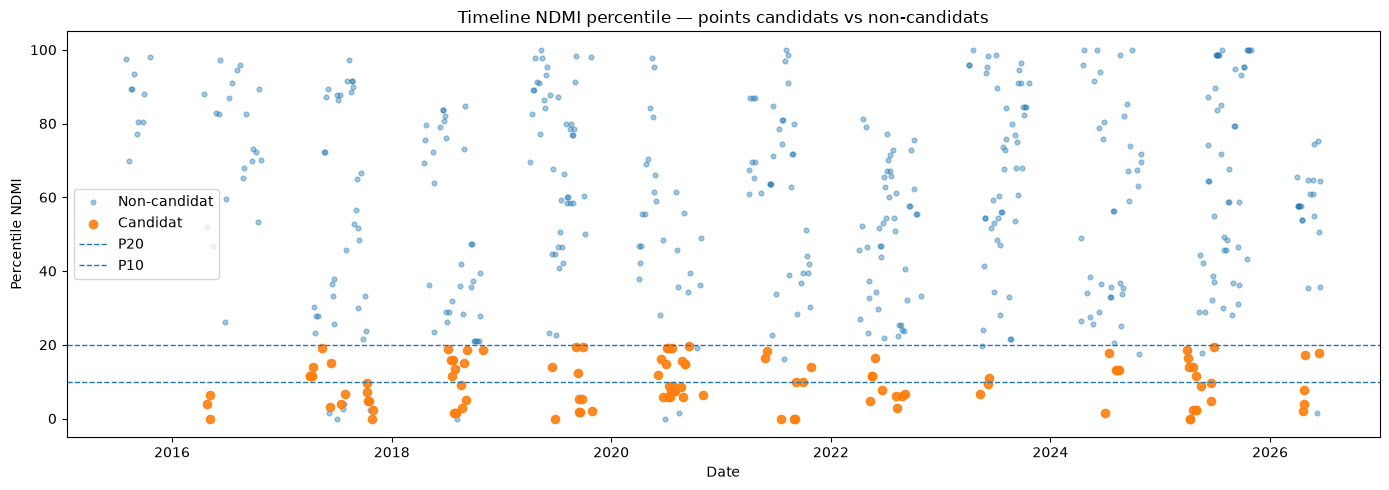

In [11]:
plot_df = decision_points.copy()
plot_df = plot_df.sort_values(date_col)

fig, ax = plt.subplots(figsize=(14, 5))

# Points normaux
normal = plot_df[~plot_df["is_candidate"].astype(bool)]
candidates = plot_df[plot_df["is_candidate"].astype(bool)]

ax.scatter(
    normal[date_col],
    normal["ndmi_percentile"],
    s=12,
    alpha=0.4,
    label="Non-candidat"
)

ax.scatter(
    candidates[date_col],
    candidates["ndmi_percentile"],
    s=35,
    alpha=0.9,
    label="Candidat"
)

ax.axhline(20, linestyle="--", linewidth=1, label="P20")
ax.axhline(10, linestyle="--", linewidth=1, label="P10")

ax.set_title("Timeline NDMI percentile — points candidats vs non-candidats")
ax.set_xlabel("Date")
ax.set_ylabel("Percentile NDMI")
ax.legend()

plt.tight_layout()
plt.show()

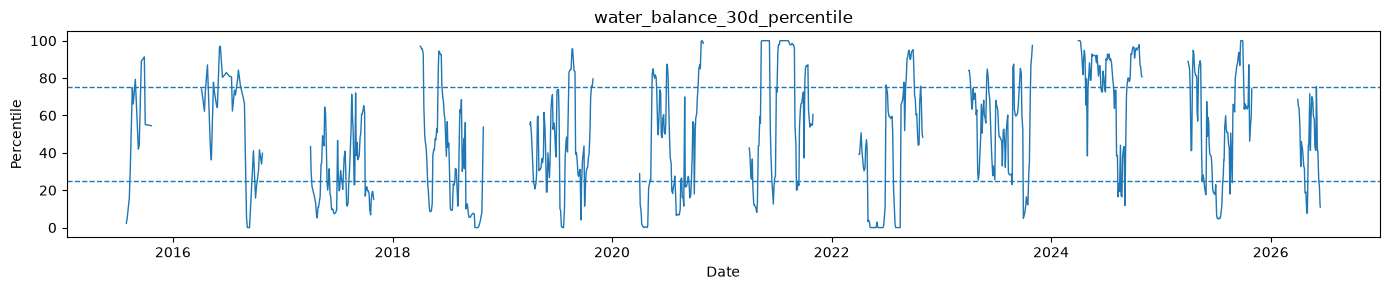

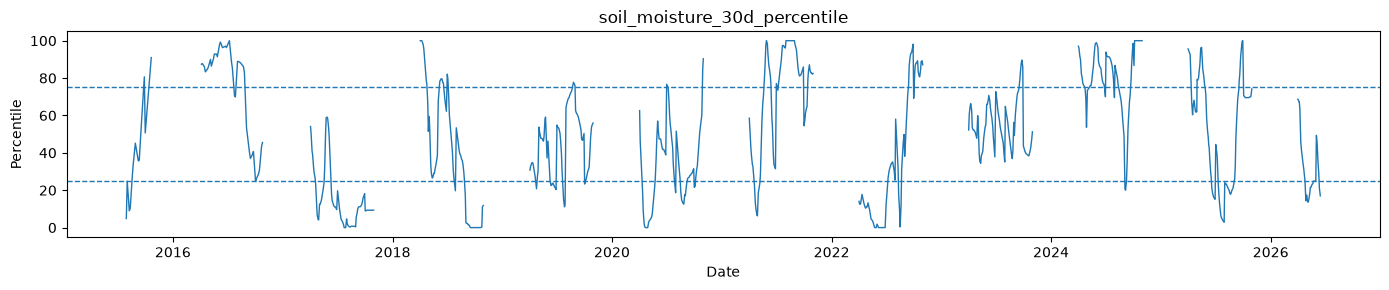

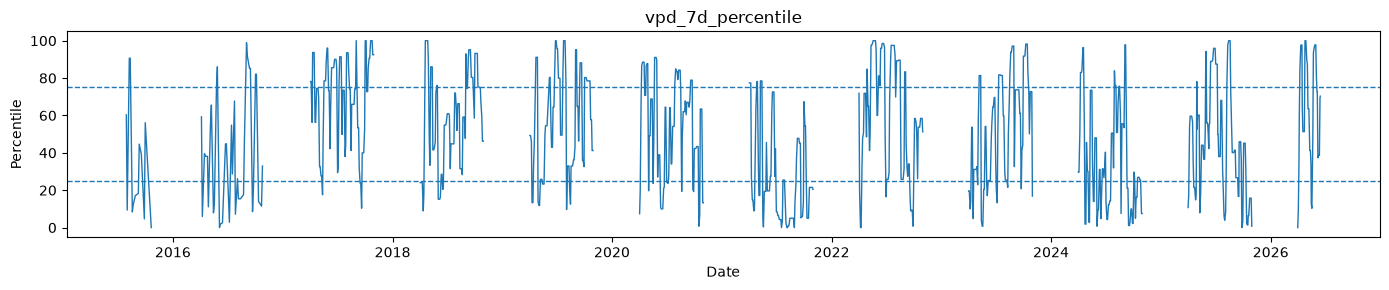

In [12]:
weather_cols = [
    "water_balance_30d_percentile",
    "soil_moisture_30d_percentile",
    "vpd_7d_percentile",
]

available_weather_cols = [c for c in weather_cols if c in decision_points.columns]

for col in available_weather_cols:
    fig, ax = plt.subplots(figsize=(14, 3))

    ax.plot(plot_df[date_col], plot_df[col], linewidth=1)
    ax.axhline(25, linestyle="--", linewidth=1)
    ax.axhline(75, linestyle="--", linewidth=1)

    ax.set_title(col)
    ax.set_xlabel("Date")
    ax.set_ylabel("Percentile")

    plt.tight_layout()
    plt.show()

In [13]:
episodes_view_cols = [
    "episode_id",
    "parcel_id",
    "episode_start_date",
    "episode_end_date",
    "duration_days",
    "decision_point_count",
    "maximum_urgency",
    "proposed_action",
    "lowest_ndmi_percentile",
    "dominant_hydro_context",
    "highest_vpd_state",
]

available_episode_cols = [c for c in episodes_view_cols if c in episodes.columns]
episodes[available_episode_cols].sort_values(
    by=[c for c in ["maximum_urgency", "episode_start_date"] if c in episodes.columns]
)

,episode_id,parcel_id,episode_start_date,episode_end_date,duration_days,decision_point_count,maximum_urgency,proposed_action,lowest_ndmi_percentile,dominant_hydro_context,highest_vpd_state
1,site_004_episode_20170403_02,site_004,2017-04-03,2017-04-13,10,5,high,priority_field_check,11.627907,dry,very_high
3,site_004_episode_20170609_04,site_004,2017-06-09,2017-06-12,3,2,high,priority_field_check,3.030303,very_dry,high
4,site_004_episode_20170717_05,site_004,2017-07-17,2017-07-29,12,2,high,priority_field_check,4.054054,very_dry,normal
5,site_004_episode_20171010_06,site_004,2017-10-10,2017-10-30,20,6,high,priority_field_check,0.000000,very_dry,very_high
6,site_004_episode_20180707_07,site_004,2018-07-07,2018-08-03,27,8,high,priority_field_check,1.449275,very_dry,normal
7,site_004_episode_20180821_08,site_004,2018-08-21,2018-09-10,20,5,high,priority_field_check,2.985075,very_dry,very_high
9,site_004_episode_20190619_10,site_004,2019-06-19,2019-06-29,10,2,high,priority_field_check,0.000000,dry,very_high
10,site_004_episode_20190907_11,site_004,2019-09-07,2019-09-30,23,7,high,priority_field_check,1.754386,dry,high
12,site_004_episode_20200606_13,site_004,2020-06-06,2020-07-31,55,14,high,priority_field_check,5.882353,very_dry,high
13,site_004_episode_20200820_14,site_004,2020-08-20,2020-09-16,27,6,high,priority_field_check,5.714286,very_dry,normal


In [14]:
print("=== Épisodes les plus longs ===")
display(
    episodes[available_episode_cols]
    .sort_values("duration_days", ascending=False)
    .head(10)
)

print("=== Épisodes avec NDMI le plus bas ===")
display(
    episodes[available_episode_cols]
    .sort_values("lowest_ndmi_percentile", ascending=True)
    .head(10)
)

if "proposed_action" in episodes.columns:
    print("=== Répartition des actions par épisode ===")
    display(episodes["proposed_action"].value_counts().to_frame("count"))

=== Épisodes les plus longs ===


,episode_id,parcel_id,episode_start_date,episode_end_date,duration_days,decision_point_count,maximum_urgency,proposed_action,lowest_ndmi_percentile,dominant_hydro_context,highest_vpd_state
12,site_004_episode_20200606_13,site_004,2020-06-06,2020-07-31,55,14,high,priority_field_check,5.882353,very_dry,high
28,site_004_episode_20250401_29,site_004,2025-04-01,2025-05-16,45,11,medium,review_raster,0.000000,normal,high
13,site_004_episode_20200820_14,site_004,2020-08-20,2020-09-16,27,6,high,priority_field_check,5.714286,very_dry,normal
6,site_004_episode_20180707_07,site_004,2018-07-07,2018-08-03,27,8,high,priority_field_check,1.449275,very_dry,normal
10,site_004_episode_20190907_11,site_004,2019-09-07,2019-09-30,23,7,high,priority_field_check,1.754386,dry,high
7,site_004_episode_20180821_08,site_004,2018-08-21,2018-09-10,20,5,high,priority_field_check,2.985075,very_dry,very_high
5,site_004_episode_20171010_06,site_004,2017-10-10,2017-10-30,20,6,high,priority_field_check,0.000000,very_dry,very_high
20,site_004_episode_20220512_21,site_004,2022-05-12,2022-05-29,17,4,high,priority_field_check,4.651163,very_dry,very_high
26,site_004_episode_20240630_27,site_004,2024-06-30,2024-07-15,15,2,medium,review_raster,1.515152,normal,normal
29,site_004_episode_20250617_30,site_004,2025-06-17,2025-06-29,12,3,high,priority_field_check,4.838710,very_dry,very_high


=== Épisodes avec NDMI le plus bas ===


,episode_id,parcel_id,episode_start_date,episode_end_date,duration_days,decision_point_count,maximum_urgency,proposed_action,lowest_ndmi_percentile,dominant_hydro_context,highest_vpd_state
0,site_004_episode_20160428_01,site_004,2016-04-28,2016-05-08,10,3,medium,review_raster,0.000000,normal,normal
5,site_004_episode_20171010_06,site_004,2017-10-10,2017-10-30,20,6,high,priority_field_check,0.000000,very_dry,very_high
9,site_004_episode_20190619_10,site_004,2019-06-19,2019-06-29,10,2,high,priority_field_check,0.000000,dry,very_high
16,site_004_episode_20210718_17,site_004,2021-07-18,2021-07-18,0,1,medium,review_raster,0.000000,normal,normal
17,site_004_episode_20210830_18,site_004,2021-08-30,2021-09-06,7,3,high,priority_field_check,0.000000,dry,normal
28,site_004_episode_20250401_29,site_004,2025-04-01,2025-05-16,45,11,medium,review_raster,0.000000,normal,high
6,site_004_episode_20180707_07,site_004,2018-07-07,2018-08-03,27,8,high,priority_field_check,1.449275,very_dry,normal
26,site_004_episode_20240630_27,site_004,2024-06-30,2024-07-15,15,2,medium,review_raster,1.515152,normal,normal
10,site_004_episode_20190907_11,site_004,2019-09-07,2019-09-30,23,7,high,priority_field_check,1.754386,dry,high
30,site_004_episode_20260421_31,site_004,2026-04-21,2026-04-26,5,4,high,priority_field_check,1.923077,very_dry,very_high


=== Répartition des actions par épisode ===


,count
proposed_action,
priority_field_check,17
review_raster,12
field_check,3


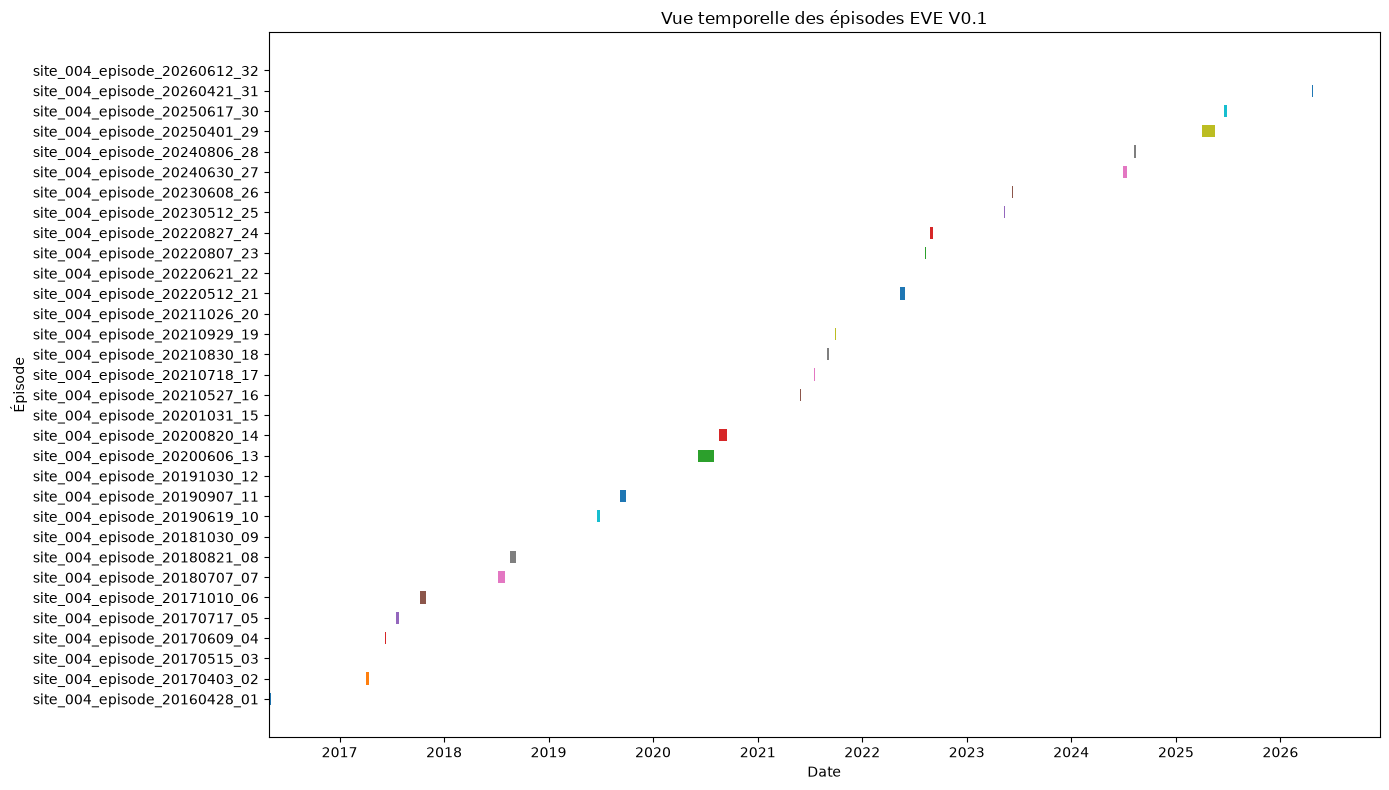

In [15]:
episodes_plot = episodes.copy()
episodes_plot = episodes_plot.sort_values("episode_start_date").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, max(6, len(episodes_plot) * 0.25)))

for i, row in episodes_plot.iterrows():
    start = row["episode_start_date"]
    end = row["episode_end_date"]
    duration = (end - start).days if pd.notna(start) and pd.notna(end) else 0

    ax.barh(
        y=i,
        width=max(duration, 1),
        left=start,
        height=0.6,
    )

ax.set_yticks(range(len(episodes_plot)))
ax.set_yticklabels(episodes_plot["episode_id"])
ax.set_title("Vue temporelle des épisodes EVE V0.1")
ax.set_xlabel("Date")
ax.set_ylabel("Épisode")

plt.tight_layout()
plt.show()

In [16]:
def show_episode(episode_id: str):
    ep = episodes[episodes["episode_id"] == episode_id]

    if ep.empty:
        print(f"Épisode introuvable : {episode_id}")
        return

    ep = ep.iloc[0]
    display(ep.to_frame("value"))

    dp = decision_points[decision_points["episode_id"] == episode_id].copy()
    dp = dp.sort_values(date_col)

    cols = [
        "decision_point_id",
        date_col,
        "ndmi_value",
        "ndmi_percentile",
        "ndmi_state",
        "satellite_quality",
        "hydro_context",
        "vpd_state",
        "persistence_state",
        "eve_decision",
        "recommended_information_action",
        "urgency",
        "justification_text",
    ]

    cols = [c for c in cols if c in dp.columns]

    print(f"\nPoints de décision associés : {len(dp)}")
    display(dp[cols])

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(dp[date_col], dp["ndmi_percentile"], marker="o")
    ax.axhline(20, linestyle="--", linewidth=1)
    ax.axhline(10, linestyle="--", linewidth=1)

    ax.set_title(f"NDMI percentile — {episode_id}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Percentile NDMI")

    plt.tight_layout()
    plt.show()

    # Exemple à remplacer par l'id exact de l'épisode août 2022
priority_episodes = episodes[
    episodes["proposed_action"].astype(str).str.contains("priority", na=False)
]

priority_episodes[available_episode_cols].head()

# show_episode("site_004_2022_episode_01")

,episode_id,parcel_id,episode_start_date,episode_end_date,duration_days,decision_point_count,maximum_urgency,proposed_action,lowest_ndmi_percentile,dominant_hydro_context,highest_vpd_state
1,site_004_episode_20170403_02,site_004,2017-04-03,2017-04-13,10,5,high,priority_field_check,11.627907,dry,very_high
3,site_004_episode_20170609_04,site_004,2017-06-09,2017-06-12,3,2,high,priority_field_check,3.030303,very_dry,high
4,site_004_episode_20170717_05,site_004,2017-07-17,2017-07-29,12,2,high,priority_field_check,4.054054,very_dry,normal
5,site_004_episode_20171010_06,site_004,2017-10-10,2017-10-30,20,6,high,priority_field_check,0.000000,very_dry,very_high
6,site_004_episode_20180707_07,site_004,2018-07-07,2018-08-03,27,8,high,priority_field_check,1.449275,very_dry,normal


In [17]:
checks = {}

checks["no_candidate_with_poor_satellite"] = not (
    decision_points["is_candidate"].astype(bool)
    & (decision_points["satellite_quality"] == "poor")
).any()

checks["no_candidate_without_episode"] = not (
    decision_points["is_candidate"].astype(bool)
    & decision_points["episode_id"].isna()
).any()

checks["no_non_candidate_with_episode"] = not (
    ~decision_points["is_candidate"].astype(bool)
    & decision_points["episode_id"].notna()
).any()

percentile_cols = [
    c for c in decision_points.columns
    if "percentile" in c
]

checks["all_percentiles_between_0_and_100"] = all(
    decision_points[c].dropna().between(0, 100).all()
    for c in percentile_cols
)

pd.DataFrame(checks.items(), columns=["check", "passed"])

,check,passed
0,no_candidate_with_poor_satellite,True
1,no_candidate_without_episode,True
2,no_non_candidate_with_episode,True
3,all_percentiles_between_0_and_100,True


In [18]:
old_candidate_dates = [
    # Remplace par tes 12 dates exactes
    # "2018-07-XX",
    # "2018-08-XX",
    # ...
]

old_candidates = pd.DataFrame({
    "old_candidate_date": pd.to_datetime(old_candidate_dates)
})

if len(old_candidates) > 0:
    merged_old = old_candidates.merge(
        decision_points,
        left_on="old_candidate_date",
        right_on=date_col,
        how="left",
    )

    cols = [
        "old_candidate_date",
        "is_candidate",
        "eve_decision",
        "recommended_information_action",
        "ndmi_percentile",
        "hydro_context",
        "vpd_state",
        "satellite_quality",
        "episode_id",
        "justification_text",
    ]

    cols = [c for c in cols if c in merged_old.columns]
    display(merged_old[cols])
else:
    print("Ajoute les 12 anciennes dates candidates pour comparer.")

Ajoute les 12 anciennes dates candidates pour comparer.


In [19]:
inspection_candidates = episodes.copy()

conditions = []

if "proposed_action" in inspection_candidates.columns:
    conditions.append(
        inspection_candidates["proposed_action"]
        .astype(str)
        .str.contains("priority", na=False)
    )

if "duration_days" in inspection_candidates.columns:
    conditions.append(inspection_candidates["duration_days"] >= 30)

if "lowest_ndmi_percentile" in inspection_candidates.columns:
    conditions.append(inspection_candidates["lowest_ndmi_percentile"] <= 5)

if conditions:
    mask = conditions[0]
    for cond in conditions[1:]:
        mask = mask | cond

    inspection_candidates = inspection_candidates[mask]

EXPORT_PATH = DATA_DIR / "top_episodes_for_raster_review_site_004.csv"
inspection_candidates.to_csv(EXPORT_PATH, index=False)

print(f"{len(inspection_candidates)} épisodes exportés vers : {EXPORT_PATH}")
display(inspection_candidates[available_episode_cols])

22 épisodes exportés vers : D:\Compte ASUS\Desktop\Eve\data\processed\top_episodes_for_raster_review_site_004.csv


,episode_id,parcel_id,episode_start_date,episode_end_date,duration_days,decision_point_count,maximum_urgency,proposed_action,lowest_ndmi_percentile,dominant_hydro_context,highest_vpd_state
0,site_004_episode_20160428_01,site_004,2016-04-28,2016-05-08,10,3,medium,review_raster,0.000000,normal,normal
1,site_004_episode_20170403_02,site_004,2017-04-03,2017-04-13,10,5,high,priority_field_check,11.627907,dry,very_high
3,site_004_episode_20170609_04,site_004,2017-06-09,2017-06-12,3,2,high,priority_field_check,3.030303,very_dry,high
4,site_004_episode_20170717_05,site_004,2017-07-17,2017-07-29,12,2,high,priority_field_check,4.054054,very_dry,normal
5,site_004_episode_20171010_06,site_004,2017-10-10,2017-10-30,20,6,high,priority_field_check,0.000000,very_dry,very_high
6,site_004_episode_20180707_07,site_004,2018-07-07,2018-08-03,27,8,high,priority_field_check,1.449275,very_dry,normal
7,site_004_episode_20180821_08,site_004,2018-08-21,2018-09-10,20,5,high,priority_field_check,2.985075,very_dry,very_high
9,site_004_episode_20190619_10,site_004,2019-06-19,2019-06-29,10,2,high,priority_field_check,0.000000,dry,very_high
10,site_004_episode_20190907_11,site_004,2019-09-07,2019-09-30,23,7,high,priority_field_check,1.754386,dry,high
11,site_004_episode_20191030_12,site_004,2019-10-30,2019-10-30,0,1,low,review_raster,2.083333,normal,normal
